# Fig 2.11, 2.12, 2.13, 2.14

Model reduction of ODE metabolic networks.

In [1]:
using OrdinaryDiffEq
using Catalyst
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

In [2]:
rn211 = @reaction_network begin
    k0, 0 --> A
    (k1, km1), A <--> B
    k2, B --> 0
end

Model ##ReactionSystem#240:
Unknowns (2): see unknowns(##ReactionSystem#240)
  A(t)
  B(t)
Parameters (4): see parameters(##ReactionSystem#240)
  k0
  k1
  km1
  k2

In [3]:
@unpack k0, k1, km1, k2, A, B = rn211
ps1 = [k0 => 0.0, k1 => 9.0, km1 => 12.0, k2 => 2.0]
u0 = [A => 0.0, B => 10.0]
tend = 3.0
sol211 = solve(ODEProblem(rn211, u0, tend, ps1))

retcode: Success
Interpolation: 3rd order Hermite
t: 34-element Vector{Float64}:
 0.0
 8.33250002662905e-6
 9.165750029291953e-5
 0.0009249075029558242
 0.0049255520098868185
 0.012950994848397006
 0.0242033909176605
 0.0386770307390286
 0.056874831424329884
 0.0788503957456076
 ⋮
 1.7517916357544254
 1.8976419863766623
 2.04653471747305
 2.199447644522893
 2.3553401128119527
 2.512411490644732
 2.6691958789164265
 2.8250502965479143
 3.0
u: 34-element Vector{Vector{Float64}}:
 [0.0, 10.0]
 [0.0009998041949395534, 9.99883355552422]
 [0.010987314386434823, 9.987180710981443]
 [0.10981641889273347, 9.871804396920822]
 [0.5587746014145984, 9.345993049721082]
 [1.3433471992221453, 8.419063000156342]
 [2.2233611282304877, 7.3619537804801425]
 [3.0603231048671335, 6.327621136104827]
 [3.7711572231276933, 5.4043546428642255]
 [4.28969045038158, 4.6657291789666395]
 ⋮
 [1.3548533333683448, 0.9254354475123455]
 [1.20381035716471, 0.8220175368337398]
 [1.0669057534967221, 0.7284268312399685]
 [0

Fig 2.11

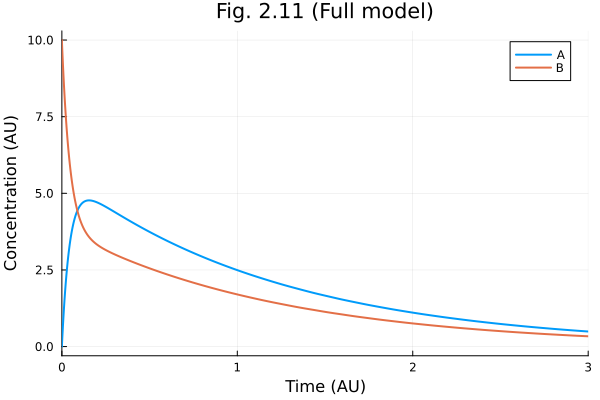

In [4]:
plot(
    sol211,
    xlabel="Time (AU)",
    ylabel="Concentration (AU)",
    title="Fig. 2.11 (Full model)"
)

## Figure 2.12 : Rapid equilibrium assumption

In [5]:
function make_212(; name)
    @parameters k0 k1 km1 k2
    @independent_variables t
    @variables A(t) B(t) C(t)
    D = Differential(t)
    eqs = [
        C ~ A + B
        B ~ C * k1 / (km1 + k1)
        D(C) ~ k0 - k2 * B
    ]
    return ODESystem(eqs, t; name)
end

make_212 (generic function with 1 method)

In [6]:
@mtkbuild model212 = make_212()

Model model212:
Equations (1):
  1 standard: see equations(model212)
Unknowns (1): see unknowns(model212)
  C(t)
Parameters (4): see parameters(model212)
  k0
  k2
  km1
  k1
Observed (2): see observed(model212)

In [7]:
unknowns(model212)

1-element Vector{SymbolicUtils.BasicSymbolic{Real}}:
 C(t)

In [8]:
observed(model212)

2-element Vector{Symbolics.Equation}:
 B(t) ~ (k1*C(t)) / (k1 + km1)
 A(t) ~ -B(t) + C(t)

In [9]:
parameters(model212)

4-element Vector{Any}:
 k0
 k2
 km1
 k1

In [10]:
independent_variables(model212)

1-element Vector{SymbolicUtils.BasicSymbolic{Real}}:
 t

In [11]:
@unpack k0, k1, km1, k2, C, A, B = model212
ps1 = [k0 => 0.0, k1 => 9.0, km1 => 12.0, k2 => 2.0]
u0 = [C => 10.0]
tend = 3.0
prob = ODEProblem(model212, u0, tend, ps1)
sol212 = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 9-element Vector{Float64}:
 0.0
 0.10313309318586757
 0.3753972361702897
 0.7370512456211995
 1.167737125797318
 1.6758020636903974
 2.2474174188288836
 2.8795734914073643
 3.0
u: 9-element Vector{Vector{Float64}}:
 [10.0]
 [9.153948340781719]
 [7.24865584846079]
 [5.3165629074890655]
 [3.6754225790588735]
 [2.377822615503587]
 [1.4567854018333606]
 [0.8473770113337572]
 [0.7642714199479234]

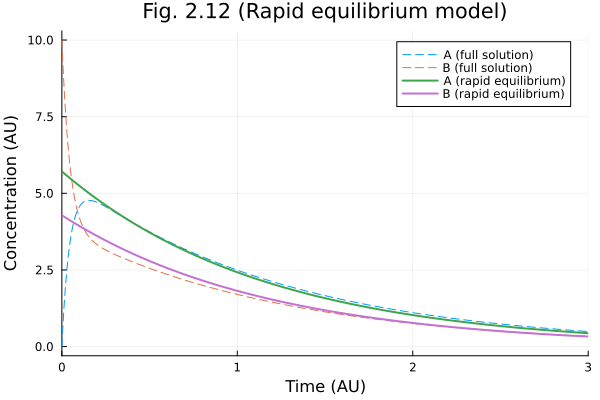

In [12]:
fig = plot(sol211, line=(:dash, 1), label=["A (full solution)" "B (full solution)"])
plot!(fig, sol212, idxs=[A, B], label=["A (rapid equilibrium)" "B (rapid equilibrium)"])
plot!(fig,
    title="Fig. 2.12 (Rapid equilibrium model)",
    xlabel="Time (AU)",
    ylabel="Concentration (AU)"
)

fig

## Figure 2.13: Rapid equilibrium (take 2)

When another set of parameters is not suitable for rapid equilibrium assumption.

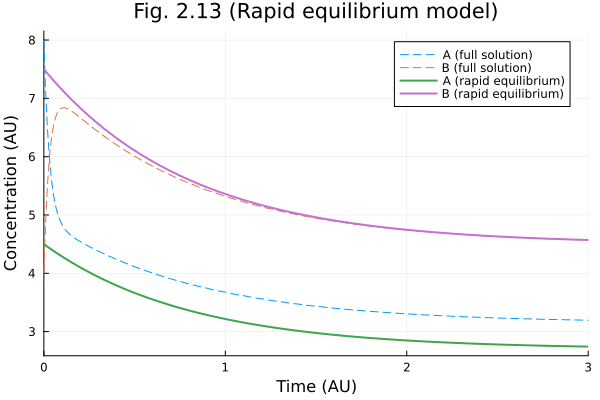

In [13]:
ps2 = [k0 => 9.0, k1 => 20.0, km1 => 12.0, k2 => 2.0]
u0 = [A => 8.0, B => 4.0]
tend = 3.0

sol213full = solve(ODEProblem(rn211, u0, tend, ps2))
sol213re = solve(ODEProblem(model212, [C => sum(last.(u0))], tend, ps2))

fig = plot(sol213full, line=(:dash, 1), label=["A (full solution)" "B (full solution)"])
plot!(fig, sol213re, idxs=[A, B], label=["A (rapid equilibrium)" "B (rapid equilibrium)"])
plot!(fig,
    title="Fig. 2.13 (Rapid equilibrium model)",
    xlabel="Time (AU)",
    ylabel="Concentration (AU)"
)

fig

## Figure 2.14 : QSSA

Quasi-steady state assumption on species A

In [14]:
function make_214(; name)
    @parameters k0 k1 km1 k2
    @independent_variables t
    @variables A(t) B(t)
    D = Differential(t)
    eqs = [
        A ~ (k0 + km1 * B) / k1
        D(B) ~ k1 * A - (km1 + k2) * B
    ]
    return ODESystem(eqs, t; name)
end

make_214 (generic function with 1 method)

In [15]:
@mtkbuild model214 = make_214()

Model model214:
Equations (1):
  1 standard: see equations(model214)
Unknowns (1): see unknowns(model214)
  B(t)
Parameters (4): see parameters(model214)
  k0
  k2
  km1
  k1
Observed (1): see observed(model214)

Initial conditions can also be represented in symbols

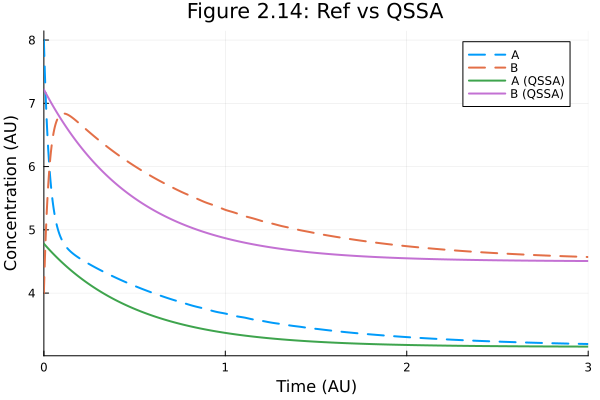

In [16]:
sol214 = solve(ODEProblem(model214, [B => (k1 * sum(last.(u0)) - k0) / (k1 + km1)], tend, ps2))

fig = plot(sol213full, line=(:dash))
plot!(fig, sol214, idxs=[A, B], label=["A (QSSA)" "B (QSSA)"])
plot!(fig,
    xlabel="Time (AU)",
    ylabel="Concentration (AU)",
    title="Figure 2.14: Ref vs QSSA",
    xlims=(0.0, tend)
)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*